# Neural Net-1

### Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from collections import Counter
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
# import scikitplot as skplt
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import jaccard_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cdist
from pandas.plotting import scatter_matrix
# from imblearn.over_sampling import SMOTE
# from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


In [2]:
from regression_evaluator import RegressionEvaluator
# Create an instance of the evaluator
evaluator = RegressionEvaluator()

In [3]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [4]:
data = pd.read_csv("./support2csv/support2.csv", delimiter = ",")
pd.set_option("display.max_columns", data.shape[1])
pd.set_option("display.max_rows", data.shape[1])
data.head(5)

,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv2m,surv6m,hday,diabetes,dementia,ca,prg2m,prg6m,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,NaN,7.000000,other,33.898438,20.0,0.262939,0.036995,1,0,0,metastatic,0.50,0.25,no dnr,5.0,97.0,6.000000,69.0,22.0,36.00000,388.00000,1.799805,0.199982,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,NaN,29.000000,white,52.695312,74.0,0.001000,0.000000,3,0,0,no,0.00,0.00,NaN,NaN,43.0,17.097656,112.0,34.0,34.59375,98.00000,NaN,NaN,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,NaN,13.000000,white,20.500000,45.0,0.790894,0.664917,4,0,0,no,0.75,0.50,no dnr,17.0,70.0,8.500000,88.0,28.0,37.39844,231.65625,NaN,2.199707,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,NaN,7.000000,white,20.097656,19.0,0.698975,0.411987,1,0,0,metastatic,0.90,0.50,no dnr,3.0,75.0,9.099609,88.0,32.0,35.00000,NaN,NaN,NaN,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,NaN,18.666656,white,23.500000,30.0,0.634888,0.532959,3,0,0,no,0.90,0.90,no dnr,16.0,59.0,13.500000,112.0,20.0,37.89844,173.31250,NaN,NaN,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [5]:
df = data.copy()

In [6]:
df.charges.isna().sum()

172

In [7]:
for i in df:
    print(f"missing values for {i}: {(df[i].isna().sum()/len(df))*100}")
    

missing values for age: 0.0
missing values for death: 0.0
missing values for sex: 0.0
missing values for hospdead: 0.0
missing values for slos: 0.0
missing values for d.time: 0.0
missing values for dzgroup: 0.0
missing values for dzclass: 0.0
missing values for num.co: 0.0
missing values for edu: 17.946183415705654
missing values for income: 32.75123558484349
missing values for scoma: 0.010982976386600769
missing values for charges: 1.8890719384953323
missing values for totcst: 9.752883031301483
missing values for totmcst: 38.165842943437674
missing values for avtisst: 0.900604063701263
missing values for race: 0.46128500823723234
missing values for sps: 0.010982976386600769
missing values for aps: 0.010982976386600769
missing values for surv2m: 0.010982976386600769
missing values for surv6m: 0.010982976386600769
missing values for hday: 0.0
missing values for diabetes: 0.0
missing values for dementia: 0.0
missing values for ca: 0.0
missing values for prg2m: 18.110928061504666
missing 

In [8]:
columns_to_check = ["scoma", "slos", "avtisst", "race", "dnrday","dnr", "surv2m", "surv6m", "sps", "aps",
                    "meanbp", "wblc", "hrt", "resp", "temp", "crea", "sod", "charges"]
df_afterdropping = df.dropna(subset=columns_to_check)

In [9]:

X = df_afterdropping.drop(["charges"], axis = 1)
y = df_afterdropping["charges"]


In [ ]:
numerical_vars_df = X.select_dtypes(include=[ 'float64'])
categorical_vars_df = X.select_dtypes(include=['int64', "object"])
obj_vars_df = X.select_dtypes(include=['object'])

numerical_df = X.select_dtypes(["float64"])
numerical_cols = list(numerical_vars_df.columns)
additional_cols = ['death', 'hospdead', 'd.time', 'num.co', 'hday', 'diabetes', 'dementia']
numerical_cols.extend(additional_cols)
numerical_cols = list(set(numerical_cols))

ordinal_cols = ['income', 'sfdm2']

onehot_cols = categorical_vars_df.drop(["income", "sfdm2",'death', 'hospdead',
       'd.time', 'num.co', 'hday', 'diabetes', 'dementia'], axis = 1).columns
print(ordinal_cols)
print(numerical_cols)
print(onehot_cols)

['income', 'sfdm2']
['adlp', 'sod', 'adls', 'crea', 'resp', 'edu', 'surv2m', 'wblc', 'adlsc', 'age', 'bun', 'dnrday', 'num.co', 'ph', 'hday', 'prg2m', 'alb', 'surv6m', 'scoma', 'totmcst', 'death', 'glucose', 'totcst', 'hospdead', 'aps', 'sps', 'dementia', 'pafi', 'hrt', 'temp', 'meanbp', 'bili', 'diabetes', 'prg6m', 'avtisst', 'd.time', 'urine']
Index(['sex', 'slos', 'dzgroup', 'dzclass', 'race', 'ca', 'dnr'], dtype='object')


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((6863, 46), (6863,), (1716, 46), (1716,))

In [12]:
# Transform the target variable
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [13]:
# Define the preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    # ('robust_scaler', RobustScaler())
    ("standard_scaler", StandardScaler())
    
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['under $11k', '$11-$25k', '$25-$50k', '>$50k'], ['Coma or Intub', 'SIP>=30', 'adl>=4 (>=5 if sur)', 'no(M2 and SIP pres)', '<2 mo. follow-up']])),
    # ('scaler', RobustScaler())
    ("standard_scaler", StandardScaler())
])
onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # ('dummify', FunctionTransformer(dummify)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output = False)),
    # ('scaler', RobustScaler())
    ("standard_scaler", StandardScaler())
])



preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('ordinal_cat', ordinal_transformer, ordinal_cols),
        ("onehot_cat", onehot_transformer, onehot_cols)
    ])


charges_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # ("SMOTE", SMOTE(random_state = 42))
])

reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ("linear regression", LinearRegression())])






### linear regression

In [14]:
# reg.fit(X_train, y_train)
reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['adlp', 'sod', 'adls',
                                                   'crea', 'resp', 'edu',
                                                   'surv2m', 'wblc', 'adlsc',
                                                   'age', 'bun', 'dnrday',
                                                   'num.co', 'ph', 'hday',
                                                   'prg2m', 'alb', 'surv6m',
                                                   'scoma', 'totmcst', 'death',
                                                   'glucose', 'totcst',
                                                   'hospdead', 'aps', 'sps...
                                                                   StandardScaler())]),
                                                  ['income', 'sfdm2']),
                                                 ('onehot_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False)),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  Index(['sex', 'slos', 'dzgroup', 'dzclass', 'race', 'ca', 'dnr'], dtype='object'))])),
                ('linear regression', LinearRegression())])

In [15]:

print('Coefficients: \n', reg.named_steps["linear regression"].coef_)
print('Intercept: \n', reg.named_steps["linear regression"].intercept_)

Coefficients: 
 [-0.00790727 -0.00400938 -0.12630254 -0.00436135 -0.01884553  0.05860431
 -0.08201083  0.00097499  0.12019032 -0.05250988  0.02402967  0.01386709
 -0.02340545  0.01731514  0.16304992 -0.01001219  0.0086151   0.00264653
  0.01660472  0.04244866 -0.07345343 -0.00185326  0.2793697   0.04783898
  0.03520786 -0.02668108 -0.01983368 -0.00364308 -0.00336896  0.03340873
 -0.01005942  0.03704064 -0.01296869  0.0334522   0.31353588 -0.08963095
  0.01529687  0.0350208   0.01693699 -0.00226665  0.00226665 -0.17181164
 -0.22916786 -0.20921632 -0.14849835 -0.08668638 -0.05849587 -0.03565191
 -0.01963774  0.00539495  0.01024446  0.02267955  0.04693259  0.04569375
  0.04666974  0.05752172  0.05146789  0.06544515  0.05733172  0.05231075
  0.05373609  0.06213136  0.05048207  0.06613946  0.06595184  0.06628676
  0.06094135  0.05749866  0.05364298  0.05293549  0.04702862  0.04134274
  0.05516214  0.0495355   0.04552269  0.065286    0.0526594   0.05632329
  0.05645095  0.03669512  0.0468791

In [16]:
y_pred = reg.predict(X_test)


LinearRegression Performance Metrics:
R² Score: 0.841
MSE: 0.259
RMSE: 0.509
MAE: 0.377
{'r2': 0.8406280946263917, 'mse': 0.2587485946827585, 'rmse': 0.5086733673810322, 'mae': 0.37663410269658604}


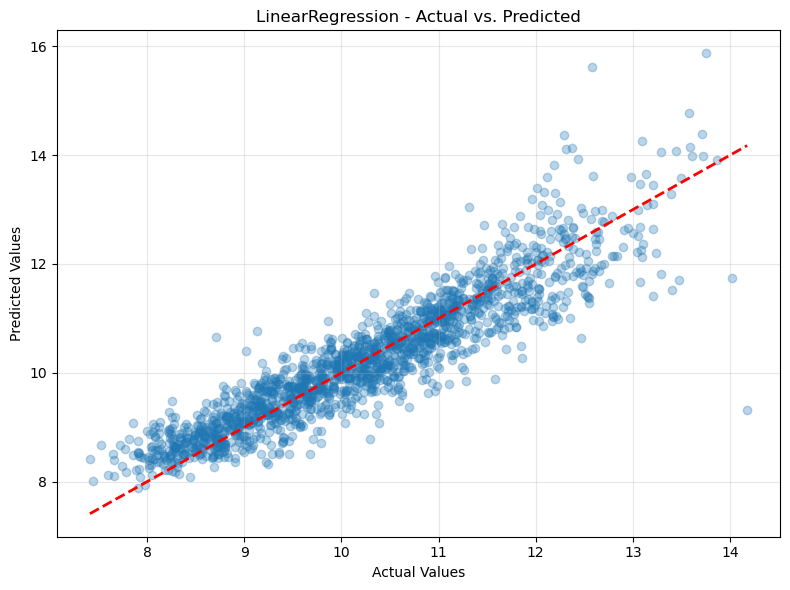

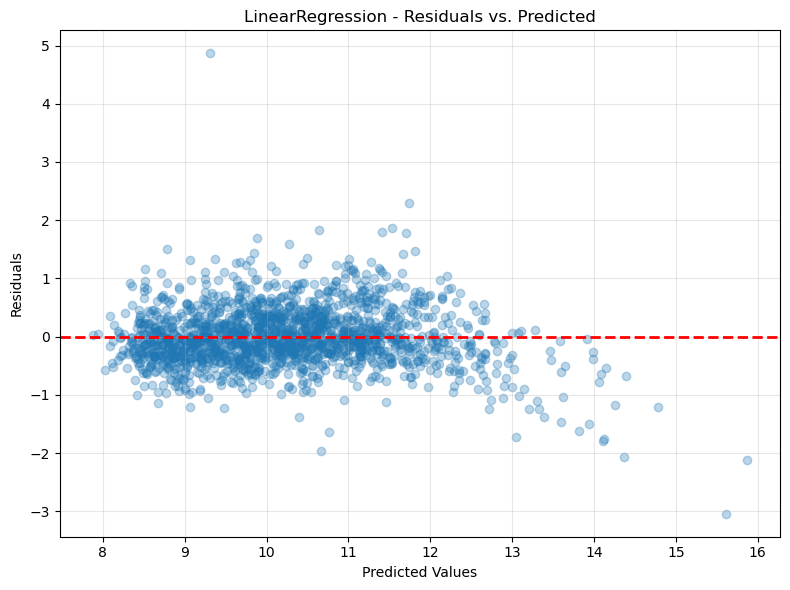

In [17]:
from regression_evaluator import RegressionEvaluator


# Now use the instance methods
lr_metrics = evaluator.evaluate_model(y_test, y_pred, "LinearRegression")
print(lr_metrics)

# Create plots using the instance
evaluator.plot_actual_vs_predicted(y_test, y_pred, "LinearRegression")
evaluator.plot_residuals_vs_predicted(y_test, y_pred, "LinearRegression")

### Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
random_forest = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42))
])
random_forest.fit(X_train, y_train)
y_pred = random_forest.predict(X_test)

In [19]:
random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['adlp', 'sod', 'adls',
                                                   'crea', 'resp', 'edu',
                                                   'surv2m', 'wblc', 'adlsc',
                                                   'age', 'bun', 'dnrday',
                                                   'num.co', 'ph', 'hday',
                                                   'prg2m', 'alb', 'surv6m',
                                                   'scoma', 'totmcst', 'death',
                                                   'glucose', 'totcst',
                                                   'hospdead', 'aps', 'sps...
                                                                   StandardScaler())]),
                                                  ['income', 'sfdm2']),
                                                 ('onehot_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False)),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  Index(['sex', 'slos', 'dzgroup', 'dzclass', 'race', 'ca', 'dnr'], dtype='object'))])),
                ('rf', RandomForestRegressor(random_state=42))])


RandomForestRegressor Performance Metrics:
R² Score: 0.939
MSE: 0.099
RMSE: 0.315
MAE: 0.186


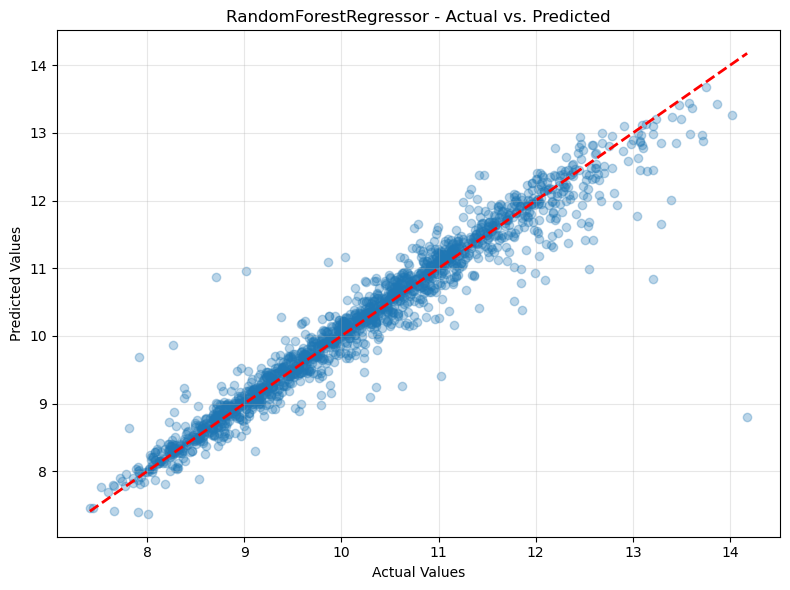

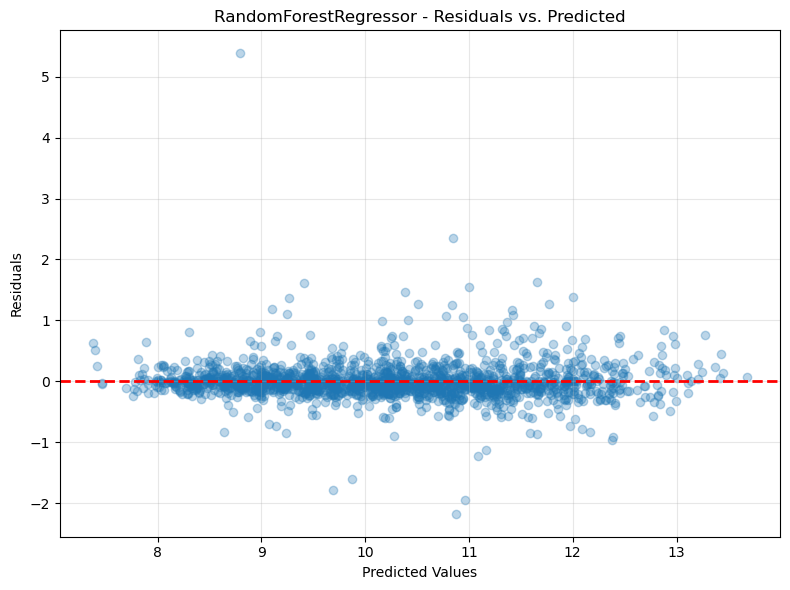

In [20]:
rf_metrics = evaluator.evaluate_model(y_test, y_pred, "RandomForestRegressor")
evaluator.plot_actual_vs_predicted(y_test, y_pred, "RandomForestRegressor")
evaluator.plot_residuals_vs_predicted(y_test, y_pred, "RandomForestRegressor")

### Gradient boost

In [21]:
gradient_boost = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', GradientBoostingRegressor(n_estimators=100, random_state=42))
])
gradient_boost.fit(X_train, y_train)
y_pred = gradient_boost.predict(X_test)




GradientBoostingRegressor Performance Metrics:
R² Score: 0.932
MSE: 0.110
RMSE: 0.331
MAE: 0.208


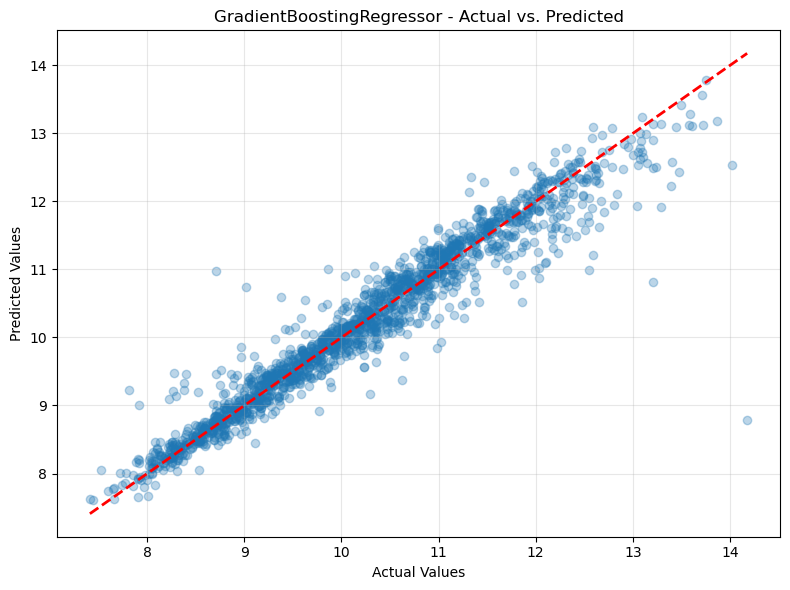

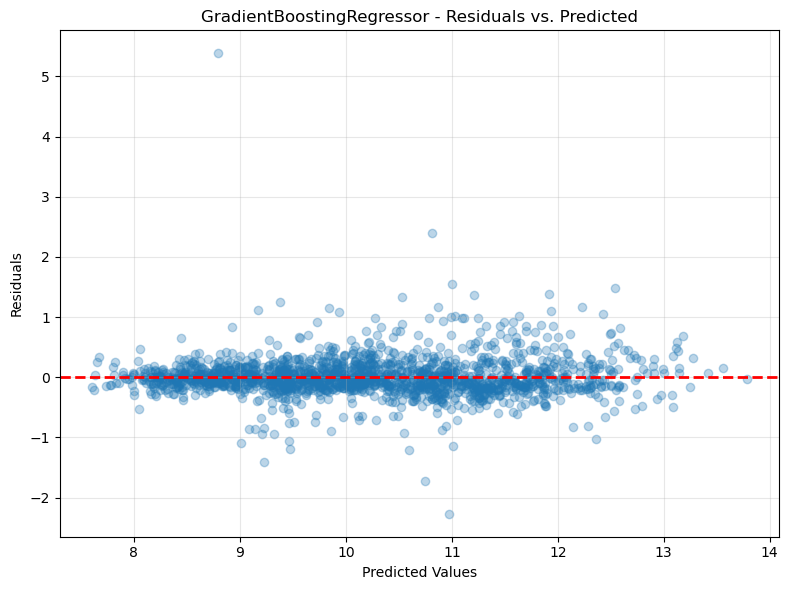

In [22]:
gb_metrics = evaluator.evaluate_model(y_test, y_pred, "GradientBoostingRegressor")
evaluator.plot_actual_vs_predicted(y_test, y_pred, "GradientBoostingRegressor")
evaluator.plot_residuals_vs_predicted(y_test, y_pred, "GradientBoostingRegressor")



### LASSO

In [23]:
reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ("lasso", Lasso())])
reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['adlp', 'sod', 'adls',
                                                   'crea', 'resp', 'edu',
                                                   'surv2m', 'wblc', 'adlsc',
                                                   'age', 'bun', 'dnrday',
                                                   'num.co', 'ph', 'hday',
                                                   'prg2m', 'alb', 'surv6m',
                                                   'scoma', 'totmcst', 'death',
                                                   'glucose', 'totcst',
                                                   'hospdead', 'aps', 'sps...
                                                                                               'follow-up']])),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['income', 'sfdm2']),
                                                 ('onehot_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False)),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  Index(['sex', 'slos', 'dzgroup', 'dzclass', 'race', 'ca', 'dnr'], dtype='object'))])),
                ('lasso', Lasso())])

In [24]:
print('Coefficients: \n', reg.named_steps["lasso"].coef_) #coefficient for each column/feature
print('Intercept: \n', reg.named_steps["lasso"].intercept_)

Coefficients: 
 [ 0.  0. -0.  0.  0.  0. -0.  0.  0. -0.  0.  0. -0.  0.  0. -0. -0. -0.
  0.  0. -0.  0.  0.  0.  0.  0. -0. -0.  0.  0. -0.  0. -0. -0.  0. -0.
  0.  0.  0.  0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0. -0. -0. -0. -0.  0. -0.  0.  0. -0. -0.  0.  0. -0.  0.  0. -0. -0.
  0.  0.  0. -0. -0.]
Intercept: 
 10.199809654543115



Lasso Performance Metrics:
R² Score: 0.932
MSE: 0.110
RMSE: 0.331
MAE: 0.208


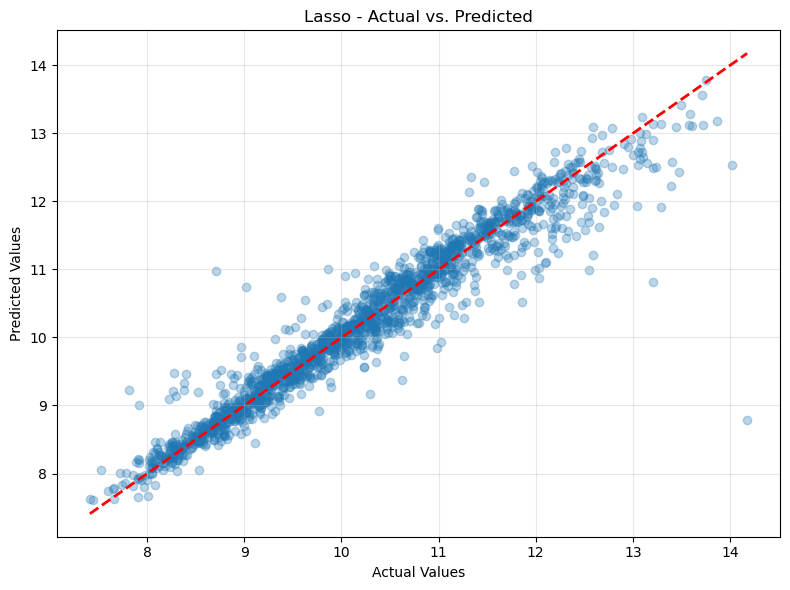

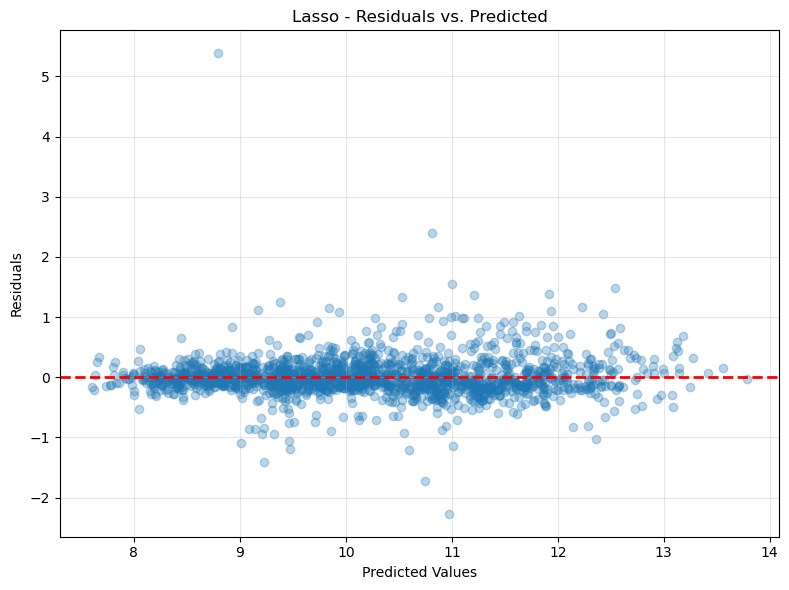

In [25]:
lasso_metrics = evaluator.evaluate_model(y_test, y_pred, "Lasso")
evaluator.plot_actual_vs_predicted(y_test, y_pred, "Lasso")
evaluator.plot_residuals_vs_predicted(y_test, y_pred, "Lasso")

### Ridge

In [26]:
reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ("Ridge", Ridge())])
reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['adlp', 'sod', 'adls',
                                                   'crea', 'resp', 'edu',
                                                   'surv2m', 'wblc', 'adlsc',
                                                   'age', 'bun', 'dnrday',
                                                   'num.co', 'ph', 'hday',
                                                   'prg2m', 'alb', 'surv6m',
                                                   'scoma', 'totmcst', 'death',
                                                   'glucose', 'totcst',
                                                   'hospdead', 'aps', 'sps...
                                                                                               'follow-up']])),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['income', 'sfdm2']),
                                                 ('onehot_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False)),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  Index(['sex', 'slos', 'dzgroup', 'dzclass', 'race', 'ca', 'dnr'], dtype='object'))])),
                ('Ridge', Ridge())])

In [27]:
print('Coefficients: \n', reg.named_steps["Ridge"].coef_) #coefficient for each column/feature
print('Intercept: \n', reg.named_steps["Ridge"].intercept_)

Coefficients: 
 [-0.00789007 -0.00400338 -0.12602168 -0.00435971 -0.01884955  0.05860201
 -0.08132229  0.00097854  0.11989321 -0.05249855  0.02402397  0.01441915
 -0.02340449  0.01731529  0.16303978 -0.00999035  0.00861275  0.00206318
  0.01667447  0.04255146 -0.07341069 -0.00185079  0.27931077  0.04781311
  0.03522142 -0.02659687 -0.01981239 -0.00365602 -0.00335124  0.03340968
 -0.01006426  0.03703981 -0.01296675  0.03342052  0.31342441 -0.08957245
  0.01529412  0.03501011  0.01693724 -0.00226667  0.00226667 -0.17171347
 -0.22902818 -0.20909059 -0.14839432 -0.08660657 -0.05843368 -0.0355967
 -0.01959468  0.00543401  0.010272    0.02269456  0.04693387  0.04569521
  0.04666897  0.05751363  0.05146007  0.06543213  0.05731511  0.05229352
  0.0537154   0.0621041   0.05045844  0.06610657  0.06592072  0.06625623
  0.06091309  0.05746923  0.05361308  0.05290813  0.04699357  0.04130767
  0.05512944  0.04949833  0.04548295  0.06523936  0.0526145   0.05627988
  0.05640213  0.03664768  0.04684212


Ridge Performance Metrics:
R² Score: 0.841
MSE: 0.259
RMSE: 0.509
MAE: 0.377


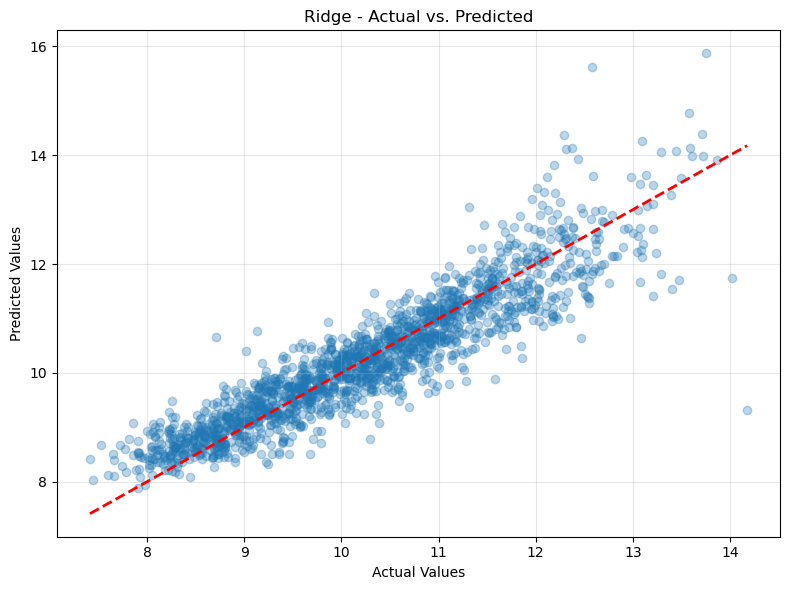

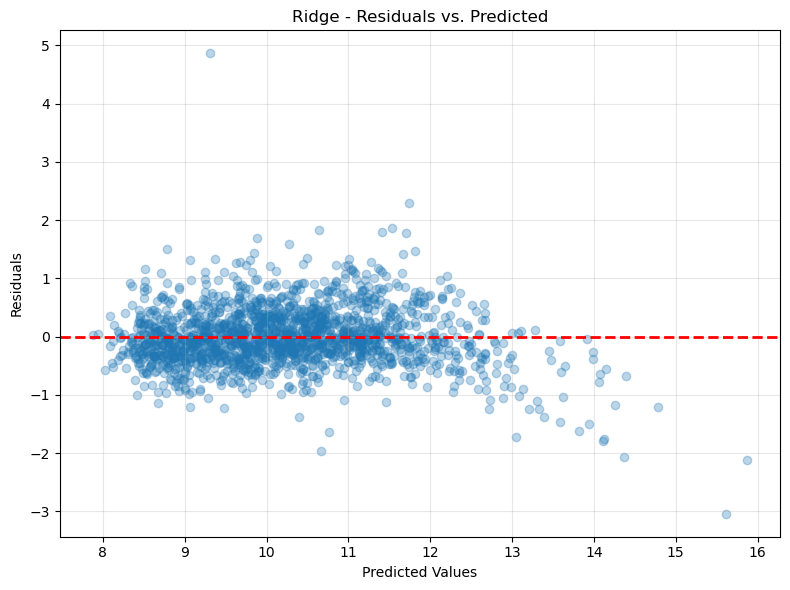

In [28]:
y_pred = reg.predict(X_test)
ridge_metrics = evaluator.evaluate_model(y_test, y_pred, "Ridge")
evaluator.plot_actual_vs_predicted(y_test, y_pred, "Ridge")
evaluator.plot_residuals_vs_predicted(y_test, y_pred, "Ridge")

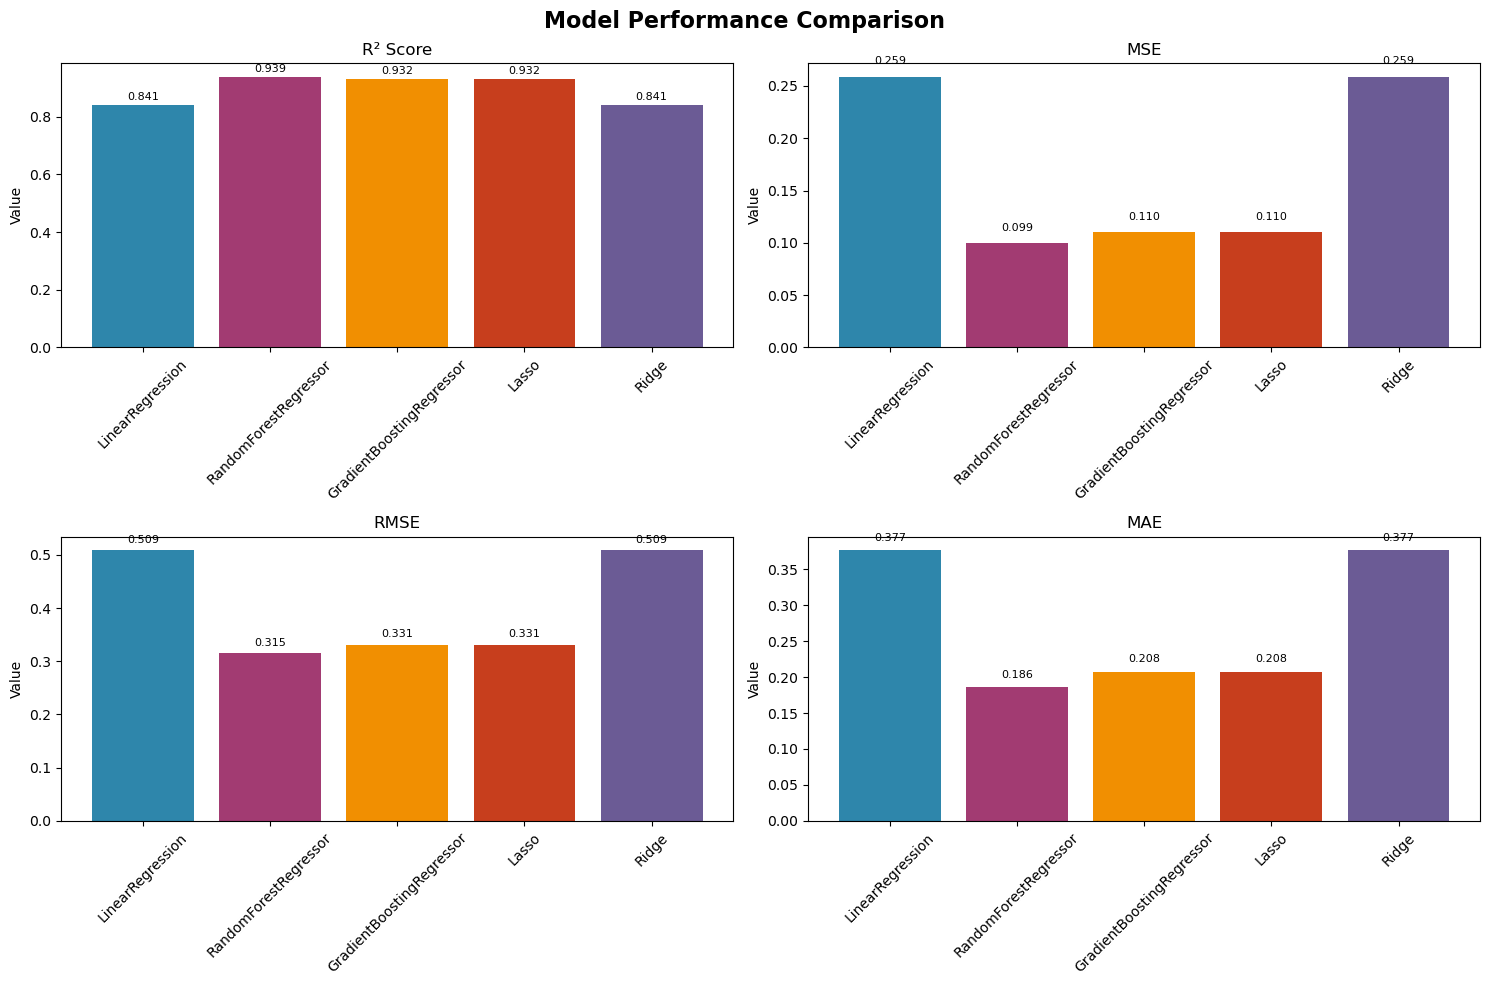

In [29]:
evaluator.plot_model_comparison()

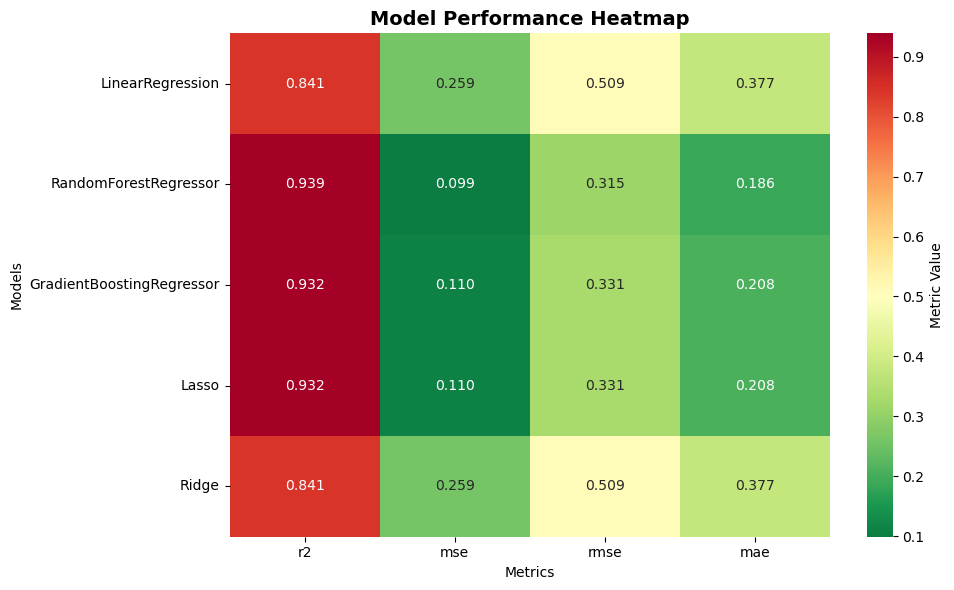

In [30]:
evaluator.plot_heatmap_comparison()

In [31]:
ridge_metrics, lasso_metrics, gb_metrics, rf_metrics, lr_metrics

({'r2': 0.8406445881697359,
  'mse': 0.25872181655551174,
  'rmse': 0.5086470451654189,
  'mae': 0.3766203280740513},
 {'r2': 0.932360036275427,
  'mse': 0.1098170064359681,
  'rmse': 0.3313864910281771,
  'mae': 0.20779345711817926},
 {'r2': 0.932360036275427,
  'mse': 0.1098170064359681,
  'rmse': 0.3313864910281771,
  'mae': 0.20779345711817926},
 {'r2': 0.938796632119126,
  'mse': 0.09936685761460733,
  'rmse': 0.31522509039511326,
  'mae': 0.18588141210769343},
 {'r2': 0.8406280946263917,
  'mse': 0.2587485946827585,
  'rmse': 0.5086733673810322,
  'mae': 0.37663410269658604})

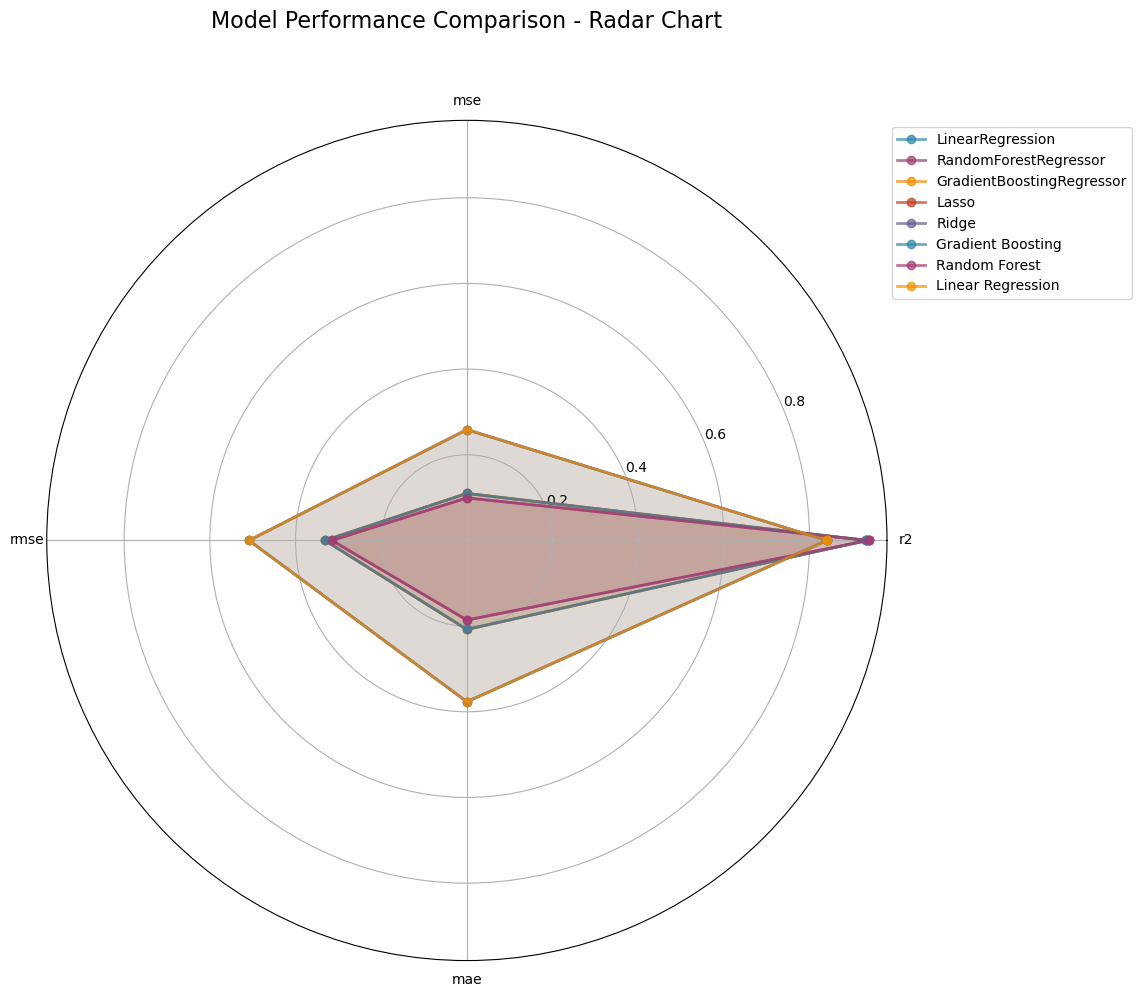

In [ ]:
evaluator.models_metrics['Ridge'] = ridge_metrics
evaluator.models_metrics['Lasso'] = lasso_metrics
evaluator.models_metrics['Gradient Boosting'] = gb_metrics
evaluator.models_metrics['Random Forest'] = rf_metrics
evaluator.models_metrics['Linear Regression'] = lr_metrics
evaluator.plot_radar_chart_comparison()

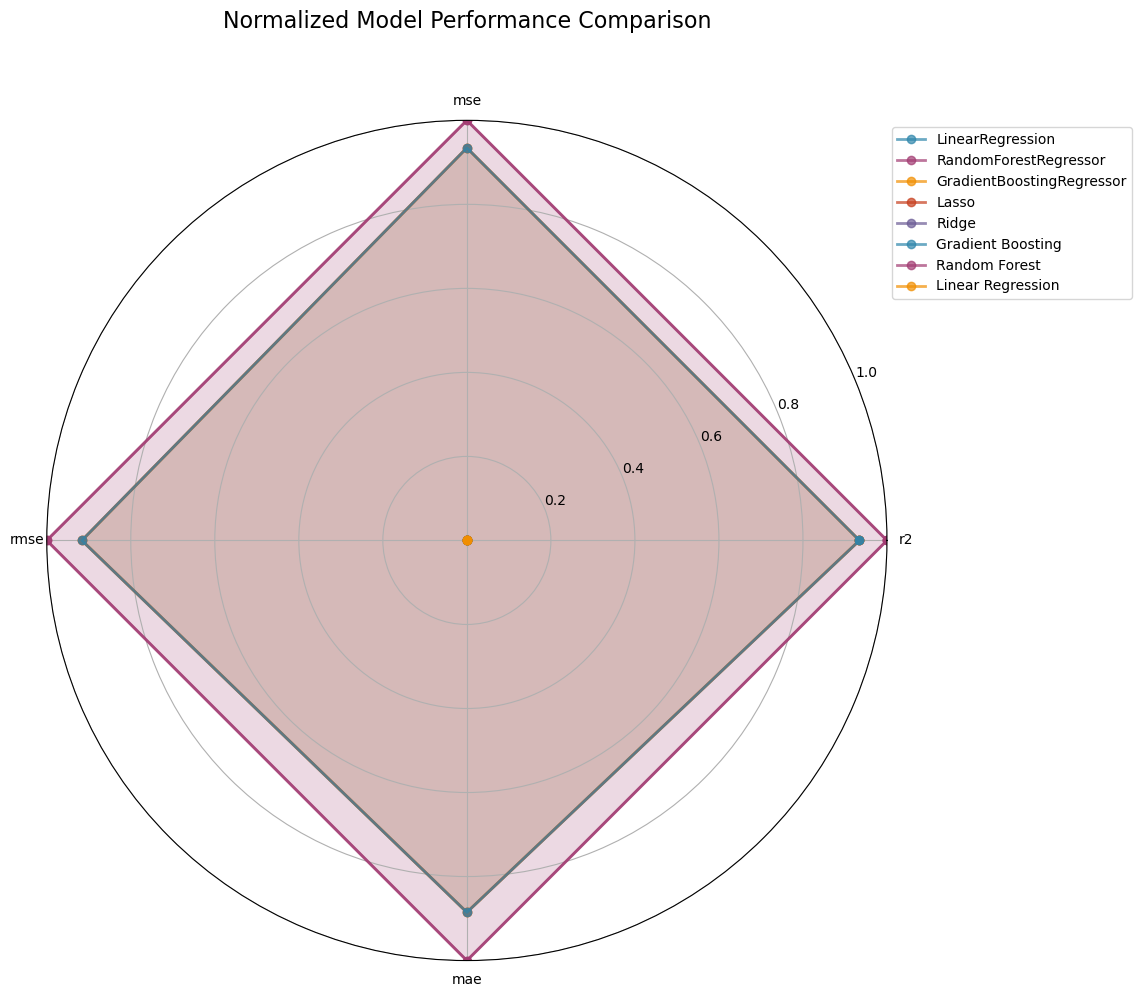

In [33]:
evaluator.plot_radar_chart_normalized()

In [34]:
evaluator.get_best_model()

Best model by r2: RandomForestRegressor (0.939)


'RandomForestRegressor'

In [35]:
evaluator.print_summary()


MODEL PERFORMANCE SUMMARY
                              r2    mse   rmse    mae
LinearRegression           0.841  0.259  0.509  0.377
RandomForestRegressor      0.939  0.099  0.315  0.186
GradientBoostingRegressor  0.932  0.110  0.331  0.208
Lasso                      0.932  0.110  0.331  0.208
Ridge                      0.841  0.259  0.509  0.377
Gradient Boosting          0.932  0.110  0.331  0.208
Random Forest              0.939  0.099  0.315  0.186
Linear Regression          0.841  0.259  0.509  0.377

BEST MODELS BY METRIC:
------------------------------
Best model by r2: RandomForestRegressor (0.939)
Best model by mse: RandomForestRegressor (0.099)
Best model by rmse: RandomForestRegressor (0.315)
Best model by mae: RandomForestRegressor (0.186)


### MLP

In [87]:
# X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6863, 65), (1716, 65), (6863,), (1716,))

In [89]:
# from keras.models import Sequential
# from keras.layers import Dense, Dropout
# from keras.regularizers import l2, l1
# from keras.wrappers.scikit_learn import KerasClassifier
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.ensemble import VotingClassifier
# from sklearn.metrics import accuracy_score
# from sklearn.model_selection import train_test_split
# from keras.datasets import mnist
# from keras.wrappers.scikit_learn import KerasClassifier
# from keras.datasets import mnist
# from keras.models import Sequential
# from keras.utils import to_categorical
# from keras.models import Sequential
# from keras.layers import Activation, Dense, BatchNormalization, Dropout
# from keras import optimizers
# from keras.callbacks import EarlyStopping


# def mlp_model():
#     model = Sequential()

#     model.add(Dense(X_train.shape[1], input_shape = (X_train.shape[1], ), kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
#     model.add(BatchNormalization())
#     model.add(Activation('relu'))
#     model.add(Dropout(0.2))
#     model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
#     model.add(BatchNormalization())
#     model.add(Activation('relu'))
#     model.add(Dropout(0.2))
#     model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
#     model.add(BatchNormalization())
#     model.add(Activation('relu'))
#     model.add(Dropout(0.2))
#     model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
#     model.add(BatchNormalization())
#     model.add(Activation('relu'))
#     model.add(Dropout(0.2))
#     model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
#     model.add(BatchNormalization())
#     model.add(Activation('relu'))
#     model.add(Dropout(0.2))
#     # model.add(Dense(14, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
#     # model.add(BatchNormalization())
#     # model.add(Activation('relu'))
#     # model.add(Dropout(0.2))
#     model.add(Dense(1, kernel_initializer='he_normal'))
#     model.add(Activation('softmax'))

#     rms_prop=optimizers.RMSprop(1e-2)
#     sgd = optimizers.SGD(learning_rate = 0.01)
#     adam = optimizers.Adam(learning_rate = 0.001)
    
#     model.compile(optimizer = adam, loss = 'mean_squared_error', metrics = ['mse'])

#     return model

In [91]:
# model = mlp_model()
# model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 65)                4290      
                                                                 
 batch_normalization (BatchN  (None, 65)               260       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 65)                0         
                                                                 
 dropout (Dropout)           (None, 65)                0         
                                                                 
 dense_1 (Dense)             (None, 28)                1848      
                                                                 
 batch_normalization_1 (Batc  (None, 28)               112       
 hNormalization)                                        

In [ ]:
# early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# history = model.fit(X_train, y_train, validation_split = 0.2, epochs = 50, batch_size = 128, verbose = 1, callbacks = [early_stopping])

Epoch 1/50
43/43 [==============================] - 0s 11ms/step - loss: 13905256448.0000 - mse: 13905256448.0000 - val_loss: 14628125696.0000 - val_mse: 14628125696.0000
Epoch 2/50
43/43 [==============================] - 0s 7ms/step - loss: 13905253376.0000 - mse: 13905253376.0000 - val_loss: 14628125696.0000 - val_mse: 14628125696.0000
Epoch 3/50
43/43 [==============================] - 0s 8ms/step - loss: 13905254400.0000 - mse: 13905254400.0000 - val_loss: 14628125696.0000 - val_mse: 14628125696.0000
Epoch 4/50
43/43 [==============================] - 0s 8ms/step - loss: 13905254400.0000 - mse: 13905254400.0000 - val_loss: 14628125696.0000 - val_mse: 14628125696.0000
Epoch 5/50
43/43 [==============================] - 0s 8ms/step - loss: 13905256448.0000 - mse: 13905256448.0000 - val_loss: 14628125696.0000 - val_mse: 14628125696.0000
Epoch 6/50
43/43 [==============================] - 0s 8ms/step - loss: 13905253376.0000 - mse: 13905253376.0000 - val_loss: 14628125696.0000 - val_m

In [93]:
# results = model.evaluate(X_test, y_test)

54/54 [==============================] - 1s 2ms/step - loss: 16648622080.0000 - mse: 16648622080.0000


In [ ]:
# plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])
# plt.plot(history.history['loss'])
# plt.plot(history.history['val_loss'])
# plt.legend(['train acc', 'valid acc', 'train loss', 'valid loss'], loc = 'upper left')
# plt.show()